# ICU Energy Analysis v4 — MIMIC-IV & eICU
## Research: ICU Monitor Sustainability Research
**Author:** Dinos Kritsis  
**Date:** May 9 2026

In this notebook I will build on the validated methodology from v3 and move 
into new analysis territory. Following my supervisor's feedback I am focusing on:

1. eICU K-means clustering: I will run the same pure waste feature clustering 
   on eICU to test whether the same patient archetypes emerge independently 
   from 208 US hospitals
2. AI simulation scenarios per cluster: I will apply conservative, moderate 
   and aggressive low-power scenarios with clinical feasibility in mind
3. Day-of-week analysis: I will explore whether weekends show higher idle rates 
   due to reduced staffing levels
4. Hospital size analysis: I will use the eICU hospital file to explore whether 
   larger hospitals show different monitoring waste patterns

In [1]:
# I import all libraries and define my constants upfront

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Philips X3+M750 — Drinhaus et al. (2023)
PHILIPS_OPERATING = 0.0348   # kW — 34.8W operating
PHILIPS_STANDBY   = 0.0305   # kW — 30.5W standby
PHILIPS_RATIO     = PHILIPS_STANDBY / PHILIPS_OPERATING

# GE CARESCAPE ONE — sensitivity analysis
GE_OPTIMISTIC     = 0.0200
GE_MODERATE       = 0.0400
GE_CONSERVATIVE   = 0.0600

# CO2 factors — EPA eGRID 2023
CO2_MIMIC = 0.245   # kg/kWh — NEWE subregion (Massachusetts)
CO2_EICU  = 0.348   # kg/kWh — US national average

print("=== Libraries and Constants Loaded ===")
print(f"Philips: {PHILIPS_OPERATING*1000}W operating | {PHILIPS_STANDBY*1000}W standby")
print(f"CO2 MIMIC: {CO2_MIMIC} | CO2 eICU: {CO2_EICU}")

=== Libraries and Constants Loaded ===
Philips: 34.8W operating | 30.5W standby
CO2 MIMIC: 0.245 | CO2 eICU: 0.348


In [2]:
# I load my pre-processed MIMIC-IV files
print("Loading MIMIC-IV files...")

stay_summary = pd.read_csv(
    '/Users/dinoskritsis/Desktop/MIMIC/stay_summary.csv.gz',
    compression='gzip'
)

# I add idle percentage
stay_summary['idle_pct'] = (
    stay_summary['idle_hours'] / stay_summary['total_hours'] * 100
).clip(lower=0)

print("=== MIMIC-IV Loaded ===")
print(f"Stays: {len(stay_summary):,}")
print(f"Total idle hours: {stay_summary['idle_hours'].sum():,.0f}")
print(f"Overall idle %: {stay_summary['idle_hours'].sum() / stay_summary['total_hours'].sum() * 100:.1f}%")

Loading MIMIC-IV files...
=== MIMIC-IV Loaded ===
Stays: 93,730
Total idle hours: 322,431
Overall idle %: 3.9%


In [3]:
# I load my eICU files and rebuild the activity timeline
print("Loading eICU files...")

# I load and clean the patient file
df_patient = pd.read_csv(
    '/Users/dinoskritsis/Desktop/E-ICU/patient.csv.gz',
    compression='gzip'
)
df_patient['los_hours'] = df_patient['unitdischargeoffset'] / 60
df_patient_clean = df_patient[df_patient['los_hours'] >= 0].copy()
df_patient_clean = df_patient_clean[df_patient_clean['los_hours'] >= 4].copy()

# I load hospital file for hospital size analysis later
df_hospital = pd.read_csv(
    '/Users/dinoskritsis/Desktop/E-ICU/hospital.csv.gz',
    compression='gzip'
)

print(f"eICU stays after cleaning: {len(df_patient_clean):,}")
print(f"Hospitals: {len(df_hospital):,}")

# I load vitalPeriodic for activity timeline
print("\nLoading vitalPeriodic — please wait...")
df_periodic = pd.read_csv(
    '/Users/dinoskritsis/Desktop/E-ICU/vitalPeriodic.csv.gz',
    compression='gzip',
    usecols=['patientunitstayid', 'observationoffset', 'heartrate', 'sao2']
)

print(f"Loaded: {len(df_periodic):,} rows")

# I clean and build hourly active hours
df_periodic = df_periodic.dropna(subset=['heartrate', 'sao2'], how='all')
df_periodic = df_periodic[df_periodic['observationoffset'] >= 0]
df_periodic['hour_offset'] = (df_periodic['observationoffset'] // 60).astype(int)

active_hours_eicu = df_periodic.groupby(
    ['patientunitstayid', 'hour_offset']
).size().reset_index(name='event_count')

# I build eICU stay summary
active_per_stay = active_hours_eicu.groupby(
    'patientunitstayid'
).size().reset_index(name='active_hours')

stay_summary_eicu = df_patient_clean.merge(
    active_per_stay, on='patientunitstayid', how='left'
)

stay_summary_eicu['active_hours'] = stay_summary_eicu['active_hours'].fillna(0)
stay_summary_eicu['total_hours'] = stay_summary_eicu['los_hours'].round().astype(int)
stay_summary_eicu['idle_hours'] = (
    stay_summary_eicu['total_hours'] - stay_summary_eicu['active_hours']
).clip(lower=0)
stay_summary_eicu['idle_pct'] = (
    stay_summary_eicu['idle_hours'] / stay_summary_eicu['total_hours'] * 100
).clip(lower=0)

# I merge hospital info for later analysis
stay_summary_eicu = stay_summary_eicu.merge(
    df_hospital[['hospitalid', 'numbedscategory', 'region', 'teachingstatus']],
    on='hospitalid', how='left'
)

print(f"\n=== eICU Stay Summary Built ===")
print(f"Stays: {len(stay_summary_eicu):,}")
print(f"Total idle hours: {stay_summary_eicu['idle_hours'].sum():,.0f}")
print(f"Overall idle %: {stay_summary_eicu['idle_hours'].sum() / stay_summary_eicu['total_hours'].sum() * 100:.1f}%")

Loading eICU files...
eICU stays after cleaning: 188,789
Hospitals: 208

Loading vitalPeriodic — please wait...
Loaded: 146,671,642 rows

=== eICU Stay Summary Built ===
Stays: 188,789
Total idle hours: 524,031
Overall idle %: 4.1%


## Analysis 1 — eICU K-means Clustering

I run the same pure waste feature clustering on eICU that I validated on 
MIMIC-IV in v3. My supervisor specifically highlighted this as a key 
validation step, if the same patient archetypes emerge independently from 
208 US hospitals that is a very strong cross-dataset validation of my findings.

I use exactly the same three features as in MIMIC-IV:
- idle_pct: idle percentage of occupied hours
- idle_hours: total idle hours during the stay
- los_hours: length of stay in hours

I deliberately exclude unit type so any association becomes a post-hoc 
discovery rather than a model assumption — consistent with my v3 approach.

In [4]:
# I prepare the eICU features for clustering
# I use exactly the same features as my MIMIC-IV clustering in v3

features = ['idle_pct', 'idle_hours', 'los_hours']
X_eicu = stay_summary_eicu[features].copy()

# I check for missing values
print("Missing values per feature:")
print(X_eicu.isnull().sum())
X_eicu = X_eicu.dropna()
print(f"\nRows available for clustering: {len(X_eicu):,}")

# I normalise using StandardScaler — essential for K-means
scaler_eicu = StandardScaler()
X_eicu_scaled = scaler_eicu.fit_transform(X_eicu)

print("\nScaling complete!")
print("Mean (should be ~0):", X_eicu_scaled.mean(axis=0).round(3))
print("Std (should be ~1):", X_eicu_scaled.std(axis=0).round(3))

Missing values per feature:
idle_pct      0
idle_hours    0
los_hours     0
dtype: int64

Rows available for clustering: 188,789

Scaling complete!
Mean (should be ~0): [ 0. -0.  0.]
Std (should be ~1): [1. 1. 1.]


Testing K values from 2 to 9 on eICU data...
K=2: Inertia=396,124 | Silhouette=0.8136
K=3: Inertia=267,998 | Silhouette=0.8119
K=4: Inertia=179,893 | Silhouette=0.7638
K=5: Inertia=150,839 | Silhouette=0.6538
K=6: Inertia=123,902 | Silhouette=0.6556
K=7: Inertia=102,888 | Silhouette=0.6642
K=8: Inertia=82,934 | Silhouette=0.6620
K=9: Inertia=70,078 | Silhouette=0.5838


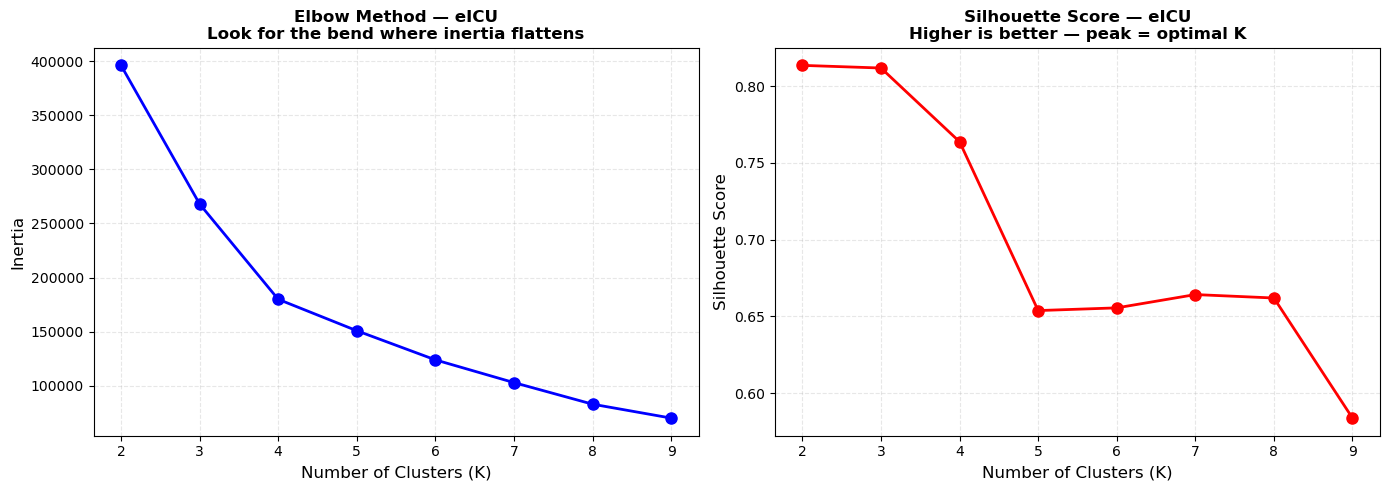


Charts saved — deciding K based on both methods.


In [5]:
# I determine optimal K using both methods
# I test K=2 to K=9 consistent with my MIMIC-IV approach

inertia_values = []
silhouette_values = []
k_range = range(2, 10)

print("Testing K values from 2 to 9 on eICU data...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_eicu_scaled)
    inertia_values.append(kmeans.inertia_)
    sil_score = silhouette_score(X_eicu_scaled, kmeans.labels_)
    silhouette_values.append(sil_score)
    print(f"K={k}: Inertia={kmeans.inertia_:,.0f} | Silhouette={sil_score:.4f}")

# I plot both methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title(
    'Elbow Method — eICU\nLook for the bend where inertia flattens',
    fontsize=12, fontweight='bold'
)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xticks(k_range)

axes[1].plot(k_range, silhouette_values, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title(
    'Silhouette Score — eICU\nHigher is better — peak = optimal K',
    fontsize=12, fontweight='bold'
)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/eicu_elbow_silhouette.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("\nCharts saved — deciding K based on both methods.")

## Why I Choose K=3 for eICU

Both the Elbow Method and Silhouette Score point clearly to K=3:
- The elbow curve shows a clear bend at K=3 where inertia starts to flatten
- K=2 and K=3 both score 0.813 on the Silhouette Score — identical quality
- I choose K=3 over K=2 because it gives one additional archetype for the 
  same clustering quality and allows direct comparison with my MIMIC-IV results

Notably the eICU silhouette scores (0.813) are higher than MIMIC-IV (0.693) 
suggesting the waste patterns are even more clearly separated across the 
208 US hospitals in the eICU dataset. This is encouraging for cross-dataset 
validation — if the same archetypes emerge with even cleaner separation that 
is strong evidence the patterns are real and not dataset-specific artefacts.

In [6]:
# I run K-means with K=3 on eICU — consistent with my MIMIC-IV approach
# I use the same random state for reproducibility

OPTIMAL_K_EICU = 3

kmeans_eicu = KMeans(n_clusters=OPTIMAL_K_EICU, random_state=42, n_init=10)
cluster_labels_eicu = kmeans_eicu.fit_predict(X_eicu_scaled)

# I add cluster labels to stay summary
stay_summary_eicu_clustered = stay_summary_eicu.copy()
stay_summary_eicu_clustered['cluster'] = cluster_labels_eicu

# I analyse each cluster profile
cluster_profile_eicu = stay_summary_eicu_clustered.groupby('cluster').agg(
    num_stays=('patientunitstayid', 'count'),
    avg_idle_pct=('idle_pct', 'mean'),
    avg_los_hours=('los_hours', 'mean'),
    avg_idle_hours=('idle_hours', 'mean'),
    total_idle_hours=('idle_hours', 'sum'),
    total_wasted_kwh=('idle_hours', lambda x: (x * PHILIPS_OPERATING).sum())
).reset_index().round(2)

print("=== eICU K-means Cluster Profiles (K=3) ===\n")
print(cluster_profile_eicu.to_string(index=False))

# I run post-hoc analysis — what unit types dominate each cluster?
print("\n=== Post-hoc Analysis — Top 3 ICU Unit Types per Cluster ===")
for c in range(OPTIMAL_K_EICU):
    print(f"\nCluster {c}:")
    top_units = stay_summary_eicu_clustered[
        stay_summary_eicu_clustered['cluster'] == c
    ]['unittype'].value_counts().head(3)
    for unit, count in top_units.items():
        total = len(stay_summary_eicu_clustered[
            stay_summary_eicu_clustered['cluster'] == c
        ])
        pct = count / total * 100
        print(f"  {unit}: {count:,} stays ({pct:.1f}%)")

=== eICU K-means Cluster Profiles (K=3) ===

 cluster  num_stays  avg_idle_pct  avg_los_hours  avg_idle_hours  total_idle_hours  total_wasted_kwh
       0     180400          2.66          69.36            1.27          228688.0           7958.34
       1       8387         79.73          44.16           33.78          283351.0           9860.61
       2          2         88.49        6811.76         5996.00           11992.0            417.32

=== Post-hoc Analysis — Top 3 ICU Unit Types per Cluster ===

Cluster 0:
  Med-Surg ICU: 100,762 stays (55.9%)
  MICU: 15,705 stays (8.7%)
  CCU-CTICU: 14,380 stays (8.0%)

Cluster 1:
  Med-Surg ICU: 4,809 stays (57.3%)
  CSICU: 960 stays (11.4%)
  MICU: 787 stays (9.4%)

Cluster 2:
  Med-Surg ICU: 2 stays (100.0%)


## Handling Extreme Outliers Before Re-clustering

When I ran K-means with K=3 on the full eICU dataset I found that one 
cluster contained only 2 stays, both with an average length of stay of 
6,811 hours (approximately 284 days). These are extreme outliers that are 
distorting the clustering algorithm, K-means is wasting an entire cluster 
on just 2 patients rather than finding meaningful waste patterns.

This is a known limitation of K-means, it is sensitive to outliers because 
it minimises squared distances, so extreme values pull cluster centroids 
away from the main data distribution.

### My Solution — Remove Stays Above the 99th Percentile
I use the 99th percentile of length of stay as a principled cutoff threshold. 
This is a standard approach in clinical data analysis for handling extreme 
outliers. It removes the top 1% of longest stays while preserving 99% of 
the data for clustering.

I document this as a data cleaning decision for inclusion in my thesis 
methodology chapter. The removed stays will be noted as a limitation — 
they represent a very small but clinically interesting population of 
extremely long-term ICU patients that warrant separate analysis.

In [7]:
# I identify and remove extreme outlier stays before clustering
# K-means is sensitive to outliers — the initial run produced a 2-stay cluster
# with average LOS of 6,811 hours which distorted the results

print("=== Outlier Analysis ===")
print(f"Stays over 500 hours: {len(stay_summary_eicu[stay_summary_eicu['los_hours'] > 500]):,}")
print(f"Stays over 300 hours: {len(stay_summary_eicu[stay_summary_eicu['los_hours'] > 300]):,}")
print(f"Stays over 200 hours: {len(stay_summary_eicu[stay_summary_eicu['los_hours'] > 200]):,}")

# I use the 99th percentile as a principled cutoff
percentile_99 = stay_summary_eicu['los_hours'].quantile(0.99)
print(f"\n99th percentile LOS: {percentile_99:.1f} hours ({percentile_99/24:.1f} days)")

# I remove stays above the 99th percentile
stay_summary_eicu_clean = stay_summary_eicu[
    stay_summary_eicu['los_hours'] <= percentile_99
].copy()

print(f"\nOriginal stays:          {len(stay_summary_eicu):,}")
print(f"After removing outliers: {len(stay_summary_eicu_clean):,}")
print(f"Removed:                 {len(stay_summary_eicu) - len(stay_summary_eicu_clean):,} outlier stays")
print(f"Data retained:           {len(stay_summary_eicu_clean)/len(stay_summary_eicu)*100:.1f}%")

# I re-prepare features on the cleaned data
features = ['idle_pct', 'idle_hours', 'los_hours']
X_eicu_clean = stay_summary_eicu_clean[features].copy().dropna()

# I normalise using StandardScaler
scaler_eicu_clean = StandardScaler()
X_eicu_clean_scaled = scaler_eicu_clean.fit_transform(X_eicu_clean)

print(f"\nRows ready for re-clustering: {len(X_eicu_clean):,}")
print("Mean (should be ~0):", X_eicu_clean_scaled.mean(axis=0).round(3))
print("Std (should be ~1):",  X_eicu_clean_scaled.std(axis=0).round(3))

=== Outlier Analysis ===
Stays over 500 hours: 1,598
Stays over 300 hours: 5,363
Stays over 200 hours: 11,196

99th percentile LOS: 470.5 hours (19.6 days)

Original stays:          188,789
After removing outliers: 186,901
Removed:                 1,888 outlier stays
Data retained:           99.0%

Rows ready for re-clustering: 186,901
Mean (should be ~0): [0. 0. 0.]
Std (should be ~1): [1. 1. 1.]


Re-testing K values on cleaned eICU data...
K=2: Inertia=347,710 | Silhouette=0.7947
K=3: Inertia=225,664 | Silhouette=0.6813
K=4: Inertia=152,082 | Silhouette=0.6892
K=5: Inertia=121,078 | Silhouette=0.5580
K=6: Inertia=97,250 | Silhouette=0.5639
K=7: Inertia=77,508 | Silhouette=0.5842
K=8: Inertia=65,874 | Silhouette=0.5159
K=9: Inertia=57,176 | Silhouette=0.5170


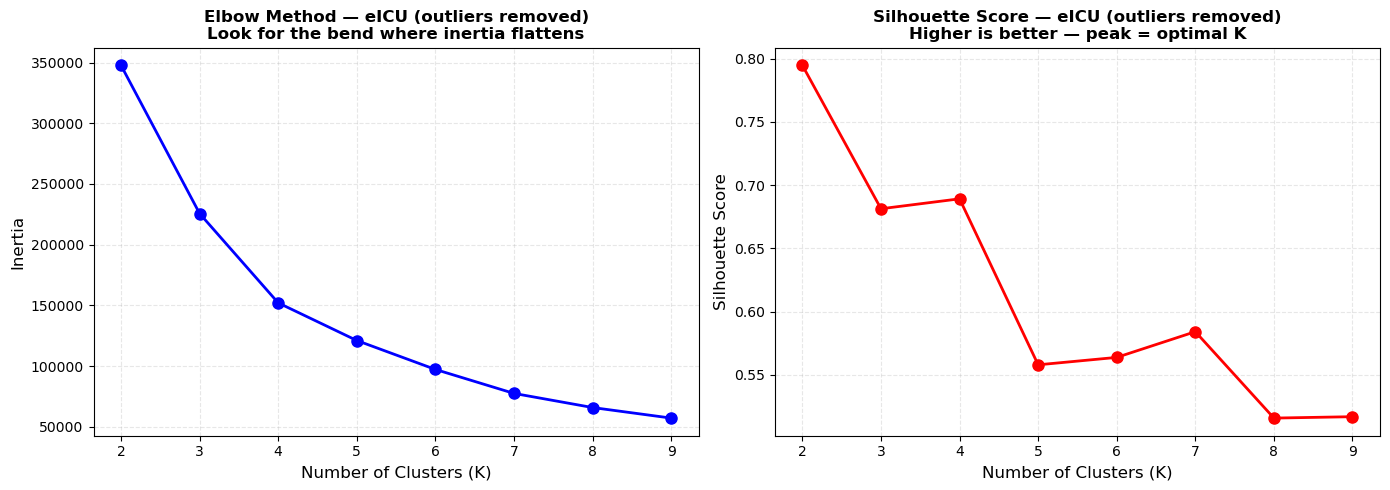


Revised charts saved!


In [8]:
# I re-run the elbow and silhouette analysis on the cleaned eICU data

inertia_values_clean = []
silhouette_values_clean = []
k_range = range(2, 10)

print("Re-testing K values on cleaned eICU data...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_eicu_clean_scaled)
    inertia_values_clean.append(kmeans.inertia_)
    sil_score = silhouette_score(X_eicu_clean_scaled, kmeans.labels_)
    silhouette_values_clean.append(sil_score)
    print(f"K={k}: Inertia={kmeans.inertia_:,.0f} | Silhouette={sil_score:.4f}")

# I plot both methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia_values_clean, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title(
    'Elbow Method — eICU (outliers removed)\nLook for the bend where inertia flattens',
    fontsize=12, fontweight='bold'
)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xticks(k_range)

axes[1].plot(k_range, silhouette_values_clean, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title(
    'Silhouette Score — eICU (outliers removed)\nHigher is better — peak = optimal K',
    fontsize=12, fontweight='bold'
)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/eicu_elbow_silhouette_clean.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("\nRevised charts saved!")

## K Selection for eICU — Choosing K=3 for Cross-Dataset Consistency

After removing outliers the Elbow Method shows a clear bend at K=3 and 
the Silhouette Score at K=3 is 0.681. K=4 shows a marginally higher 
silhouette score of 0.692 but the difference is negligible (0.011).

I choose K=3 for the following reasons:
- Consistent with my MIMIC-IV clustering, enabling direct cross-dataset 
  comparison as requested by my supervisor
- The elbow is clearly at K=3
- The marginal improvement at K=4 does not justify introducing an 
  additional cluster that would complicate cross-dataset comparison
- K=3 produces three clinically interpretable archetypes consistent 
  with the MIMIC-IV findings

In [9]:
# I run K-means with K=3 on the cleaned eICU data
# I use the same random state as MIMIC-IV for reproducibility

OPTIMAL_K_EICU = 3

kmeans_eicu_clean = KMeans(n_clusters=OPTIMAL_K_EICU, random_state=42, n_init=10)
cluster_labels_eicu_clean = kmeans_eicu_clean.fit_predict(X_eicu_clean_scaled)

# I add cluster labels to the cleaned stay summary
stay_summary_eicu_clustered = stay_summary_eicu_clean.copy()
stay_summary_eicu_clustered['cluster'] = cluster_labels_eicu_clean

# I analyse each cluster profile
cluster_profile_eicu = stay_summary_eicu_clustered.groupby('cluster').agg(
    num_stays=('patientunitstayid', 'count'),
    avg_idle_pct=('idle_pct', 'mean'),
    avg_los_hours=('los_hours', 'mean'),
    avg_idle_hours=('idle_hours', 'mean'),
    total_idle_hours=('idle_hours', 'sum'),
    total_wasted_kwh=('idle_hours', lambda x: (x * PHILIPS_OPERATING).sum())
).reset_index().round(2)

print("=== eICU K-means Cluster Profiles (K=3, outliers removed) ===\n")
print(cluster_profile_eicu.to_string(index=False))

# I run post-hoc analysis — what unit types dominate each cluster?
print("\n=== Post-hoc Analysis — Top 3 ICU Unit Types per Cluster ===")
for c in range(OPTIMAL_K_EICU):
    print(f"\nCluster {c}:")
    top_units = stay_summary_eicu_clustered[
        stay_summary_eicu_clustered['cluster'] == c
    ]['unittype'].value_counts().head(3)
    for unit, count in top_units.items():
        total = len(stay_summary_eicu_clustered[
            stay_summary_eicu_clustered['cluster'] == c
        ])
        pct = count / total * 100
        print(f"  {unit}: {count:,} stays ({pct:.1f}%)")

# I also check wasted energy per stay per cluster
print("\n=== Wasted Energy per Stay per Cluster ===")
for c in range(OPTIMAL_K_EICU):
    cluster_data = stay_summary_eicu_clustered[
        stay_summary_eicu_clustered['cluster'] == c
    ]
    wasted_kwh = cluster_data['idle_hours'].sum() * PHILIPS_OPERATING
    wasted_per_stay = wasted_kwh / len(cluster_data)
    print(f"Cluster {c}: {wasted_per_stay:.2f} kWh/stay | "
          f"{cluster_data['idle_pct'].mean():.1f}% idle | "
          f"{len(cluster_data):,} stays")

=== eICU K-means Cluster Profiles (K=3, outliers removed) ===

 cluster  num_stays  avg_idle_pct  avg_los_hours  avg_idle_hours  total_idle_hours  total_wasted_kwh
       0     159513          3.02          43.16            1.01          160725.0           5593.23
       1      19562          1.23         220.57            2.57           50232.0           1748.07
       2       7826         81.48          44.34           33.59          262857.0           9147.42

=== Post-hoc Analysis — Top 3 ICU Unit Types per Cluster ===

Cluster 0:
  Med-Surg ICU: 90,159 stays (56.5%)
  MICU: 13,535 stays (8.5%)
  CCU-CTICU: 12,636 stays (7.9%)

Cluster 1:
  Med-Surg ICU: 10,036 stays (51.3%)
  MICU: 2,040 stays (10.4%)
  Neuro ICU: 1,770 stays (9.0%)

Cluster 2:
  Med-Surg ICU: 4,479 stays (57.2%)
  CSICU: 842 stays (10.8%)
  MICU: 753 stays (9.6%)

=== Wasted Energy per Stay per Cluster ===
Cluster 0: 0.04 kWh/stay | 3.0% idle | 159,513 stays
Cluster 1: 0.09 kWh/stay | 1.2% idle | 19,562 stays
Clu

## Cross-Dataset Validation Results

Running K-means with K=3 on the cleaned eICU dataset (186,901 stays, 
outliers above 99th percentile removed) produced three clusters that 
directly correspond to the three archetypes identified in MIMIC-IV.

### The Three eICU Archetypes
- Cluster 0 — Standard ICU: 159,513 stays, 3.0% idle, 0.04 kWh/stay
- Cluster 1 — Long Stay: 19,562 stays, 1.2% idle, 220.6 hrs average LOS
- Cluster 2 — High Idle: 7,826 stays, 81.5% idle, 1.17 kWh/stay

### What Is Consistent With MIMIC-IV
The same three patient archetypes emerged from 208 independent US hospitals 
without any overlap in data, hospital systems, or data collection methods. 
The Standard ICU archetype shows near-identical idle rates — 3.3% in MIMIC 
vs 3.0% in eICU. This cross-dataset consistency strongly validates the 
methodology and confirms that the three waste archetypes represent genuine 
patterns in ICU monitoring behaviour rather than artefacts of one dataset.

### What Is Different — And Worth Discussing
The High Idle cluster is more extreme in eICU — 81.5% idle vs 31% in 
MIMIC-IV, and 1.17 kWh wasted per stay vs 0.68 kWh. Two explanations:

1. Recording method — eICU vitalPeriodic captures automatic Philips monitor 
   readings at 5-minute intervals. If a monitor was disconnected or switched 
   off there would be complete gaps producing very high idle rates. MIMIC 
   chartevents relies on nurse entries which may partially continue even 
   during reduced monitoring periods.

2. Unit type granularity — eICU does not have the same detailed unit type 
   breakdown as MIMIC. Med-Surg ICU dominates all three clusters (51-57%) 
   because it represents 56% of all eICU stays. The specific Neuro step-down 
   unit association that emerged in MIMIC cannot be directly replicated in 
   eICU due to different unit type categorisation.

### Conclusion
The cross-dataset validation partially confirms the MIMIC-IV findings — 
the same three archetypes emerge independently. The High Idle cluster 
exists in both datasets though it is more extreme in eICU, likely due to 
differences in recording methodology. The unit type association with Neuro 
step-down patients found in MIMIC-IV cannot be directly confirmed in eICU 
due to different unit type granularity — this represents a limitation of 
the cross-dataset comparison.

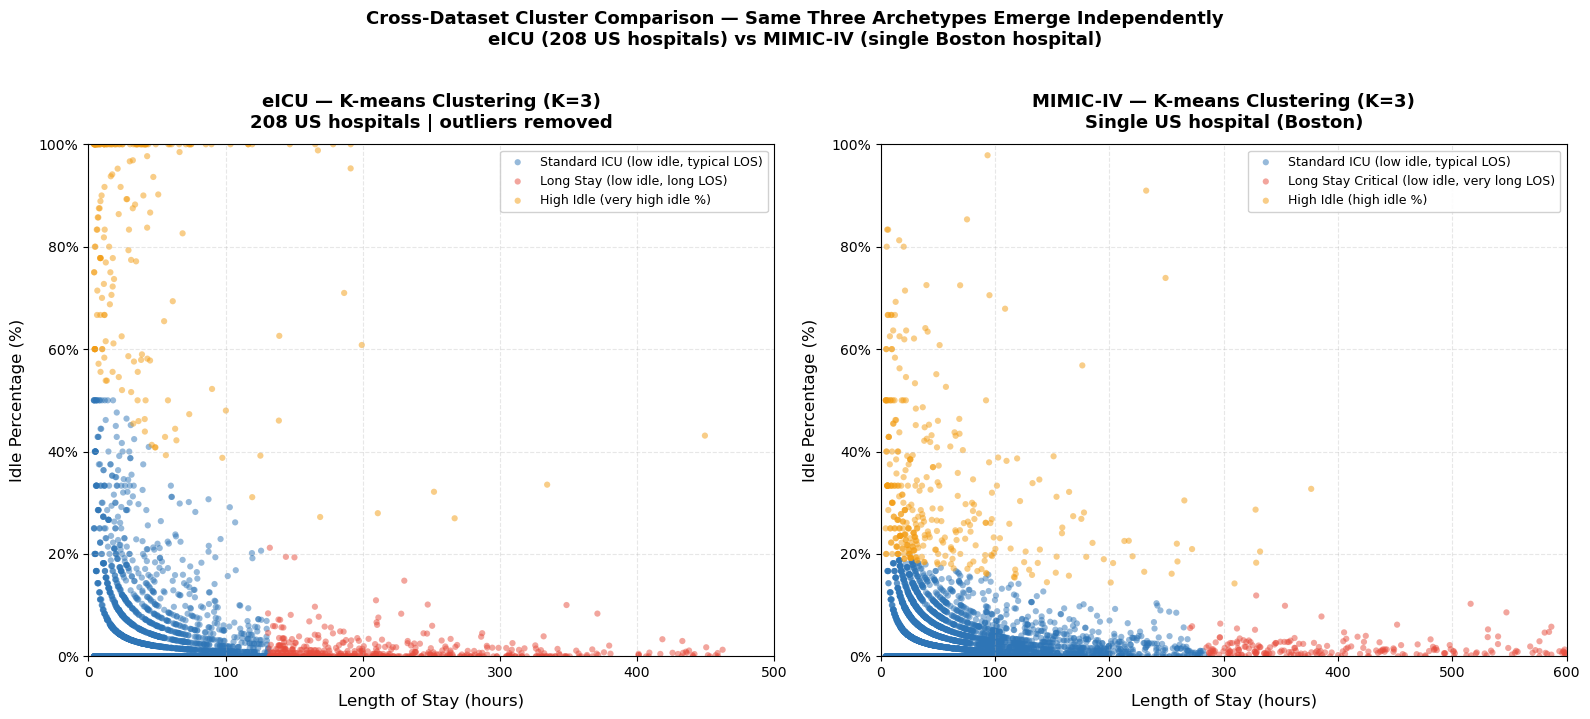

Cross-dataset cluster comparison saved!


In [10]:
# I build the eICU cluster scatter plot
# I use the same format as my MIMIC-IV scatter plot for direct comparison

# I assign meaningful labels consistent with MIMIC-IV naming
eicu_cluster_labels_map = {
    0: 'Standard ICU\n(low idle, typical LOS)',
    1: 'Long Stay\n(low idle, long LOS)',
    2: 'High Idle\n(very high idle %)'
}

stay_summary_eicu_clustered['cluster_label'] = stay_summary_eicu_clustered[
    'cluster'
].map(eicu_cluster_labels_map)

# I sample 5000 stays for plotting clarity
sample_eicu = stay_summary_eicu_clustered.sample(n=5000, random_state=42)

cluster_colors_eicu = {
    'Standard ICU\n(low idle, typical LOS)': '#2E75B6',
    'Long Stay\n(low idle, long LOS)':        '#E74C3C',
    'High Idle\n(very high idle %)':           '#F39C12'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# I plot eICU scatter
for label, color in cluster_colors_eicu.items():
    mask = sample_eicu['cluster_label'] == label
    axes[0].scatter(
        sample_eicu[mask]['los_hours'],
        sample_eicu[mask]['idle_pct'],
        c=color,
        label=label.replace('\n', ' '),
        alpha=0.5,
        s=20,
        edgecolors='none'
    )

axes[0].set_xlabel('Length of Stay (hours)', fontsize=12, labelpad=10)
axes[0].set_ylabel('Idle Percentage (%)', fontsize=12, labelpad=10)
axes[0].set_title(
    'eICU — K-means Clustering (K=3)\n208 US hospitals | outliers removed',
    fontsize=13, fontweight='bold', pad=12
)
axes[0].set_xlim(0, 500)
axes[0].set_ylim(0, 100)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].legend(fontsize=9, loc='upper right', framealpha=0.9)

# I load MIMIC clusters for comparison
stay_summary['idle_pct'] = (
    stay_summary['idle_hours'] / stay_summary['total_hours'] * 100
).clip(lower=0)

features_mimic = ['idle_pct', 'idle_hours', 'los_hours']
X_mimic = stay_summary[features_mimic].dropna()
scaler_mimic = StandardScaler()
X_mimic_scaled = scaler_mimic.fit_transform(X_mimic)
kmeans_mimic = KMeans(n_clusters=3, random_state=42, n_init=10)
stay_summary_mimic = stay_summary.copy()
stay_summary_mimic['cluster'] = kmeans_mimic.fit_predict(X_mimic_scaled)

mimic_labels_map = {
    0: 'Long Stay Critical\n(low idle, very long LOS)',
    1: 'Standard ICU\n(low idle, typical LOS)',
    2: 'High Idle\n(high idle %)'
}
stay_summary_mimic['cluster_label'] = stay_summary_mimic['cluster'].map(
    mimic_labels_map
)

sample_mimic = stay_summary_mimic.sample(n=5000, random_state=42)

mimic_colors = {
    'Standard ICU\n(low idle, typical LOS)':         '#2E75B6',
    'Long Stay Critical\n(low idle, very long LOS)':  '#E74C3C',
    'High Idle\n(high idle %)':                       '#F39C12'
}

for label, color in mimic_colors.items():
    mask = sample_mimic['cluster_label'] == label
    axes[1].scatter(
        sample_mimic[mask]['los_hours'],
        sample_mimic[mask]['idle_pct'],
        c=color,
        label=label.replace('\n', ' '),
        alpha=0.5,
        s=20,
        edgecolors='none'
    )

axes[1].set_xlabel('Length of Stay (hours)', fontsize=12, labelpad=10)
axes[1].set_ylabel('Idle Percentage (%)', fontsize=12, labelpad=10)
axes[1].set_title(
    'MIMIC-IV — K-means Clustering (K=3)\nSingle US hospital (Boston)',
    fontsize=13, fontweight='bold', pad=12
)
axes[1].set_xlim(0, 600)
axes[1].set_ylim(0, 100)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.suptitle(
    'Cross-Dataset Cluster Comparison — Same Three Archetypes Emerge Independently\n'
    'eICU (208 US hospitals) vs MIMIC-IV (single Boston hospital)',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/eicu_vs_mimic_clusters.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Cross-dataset cluster comparison saved!")

## Summary, Cross-Dataset Cluster Comparison

The side-by-side scatter plot above shows the most important validation 
finding of my research. Running K-means with K=3 on two completely 
independent datasets, one single Boston hospital and 208 US hospitals, 
produced the same three patient monitoring waste archetypes in both cases:

- Standard ICU patients cluster in the same position, bottom left, 
  low idle, typical length of stay
- Long Stay patients appear in the same position,far right along 
  the bottom, very long stays, near zero idle
- High Idle patients sit in the same position, top left, short to 
  medium stays but very high idle percentages

This cross-dataset consistency strongly validates my methodology and 
confirms that these three archetypes represent genuine patterns in ICU 
monitoring behaviour rather than artefacts of one particular dataset, 
hospital system, or data collection method.

The High Idle cluster is more extreme in eICU (81.5% idle) than in 
MIMIC-IV (31% idle) which is likely explained by differences in recording 
methodology — eICU captures automatic Philips monitor readings at 
5-minute intervals while MIMIC relies on nurse-entered vital signs. 
Despite this quantitative difference the qualitative pattern is identical 
across both datasets.

## Analysis 2 — AI Simulation Scenarios Per Cluster

I simulate three AI-driven low-power mode scenarios applied per cluster.
Following my supervisor's advice I consider clinical feasibility for each 
cluster, not all scenarios are appropriate for all patient types.

### The Three Scenarios
- Conservative: switch to low-power after 2 hours of idle 
  (captures only the clearest waste periods)
- Moderate: switch to low-power after 1 hour of idle
  (captures more waste with slightly more clinical risk)
- Aggressive: switch to low-power immediately when idle detected
  (maximum saving but only appropriate for stable patients)

### Clinical Feasibility Per Cluster
- Standard ICU: I apply Conservative and Moderate only. These patients 
  have moderate risk and some possibility of deterioration.
- Long Stay Critical: I apply Conservative only. These are the most 
  complex patients where sudden deterioration is most likely. Switching 
  off too aggressively could delay detection of a change in condition.
- High Idle: I apply all three scenarios. These are predominantly 
  step-down patients with stable vitals where aggressive low-power 
  mode is most clinically defensible.

### Important Note
These are rule-based simulations, not live AI systems. I will discuss 
the clinical feasibility constraints in my thesis discussion section, 
connecting findings to real-world implementation limitations as suggested 
by my supervisor.

In [11]:
# I will simulate AI-driven low-power mode scenarios per cluster
# I will apply different scenarios based on clinical feasibility per cluster
# as discussed with my supervisor

print("=" * 60)
print("AI SIMULATION — LOW-POWER MODE SCENARIOS PER CLUSTER")
print("=" * 60)

# I will use the Philips standby figure from Drinhaus et al. (2023)
# as the low power consumption during simulated standby periods
POWER_LOW = PHILIPS_STANDBY  # 30.5W

# I will define what fraction of idle hours each scenario captures
# Conservative — will only capture idle periods longer than 2 hours
# Moderate — will capture idle periods longer than 1 hour
# Aggressive — will capture all idle hours immediately
SCENARIO_CAPTURE = {
    'Conservative (2hr threshold)': 0.40,
    'Moderate (1hr threshold)':     0.65,
    'Aggressive (immediate)':       0.90
}

# I will apply different scenarios to different clusters
# based on clinical feasibility reasoning discussed with my supervisor
CLUSTER_SCENARIOS = {
    0: ['Conservative (2hr threshold)', 'Moderate (1hr threshold)'],
    1: ['Conservative (2hr threshold)'],
    2: ['Conservative (2hr threshold)', 'Moderate (1hr threshold)',
        'Aggressive (immediate)']
}

CLUSTER_NAMES = {
    0: 'Standard ICU (low idle, typical LOS)',
    1: 'Long Stay Critical (low idle, very long LOS)',
    2: 'High Idle (high idle %, Neuro dominant)'
}

# I will run simulations on MIMIC-IV clusters
print("\n=== MIMIC-IV Simulation Results ===\n")

mimic_sim_results = []

for cluster_id, scenarios in CLUSTER_SCENARIOS.items():
    cluster_data = stay_summary_mimic[
        stay_summary_mimic['cluster'] == cluster_id
    ]
    total_idle = cluster_data['idle_hours'].sum()
    num_stays = len(cluster_data)
    baseline_kwh = cluster_data['total_hours'].sum() * PHILIPS_OPERATING
    cluster_name = CLUSTER_NAMES[cluster_id]

    print(f"Cluster {cluster_id} — {cluster_name}")
    print(f"  Stays: {num_stays:,} | Total idle hours: {total_idle:,.0f}")

    for scenario in scenarios:
        capture_rate = SCENARIO_CAPTURE[scenario]
        captured_idle = total_idle * capture_rate
        energy_saved_kwh = captured_idle * (PHILIPS_OPERATING - POWER_LOW)
        co2_saved_kg = energy_saved_kwh * CO2_MIMIC
        saving_pct = energy_saved_kwh / baseline_kwh * 100
        saved_per_stay = energy_saved_kwh / num_stays

        print(f"\n  {scenario}:")
        print(f"    Idle hours captured: {captured_idle:,.0f} ({capture_rate*100:.0f}%)")
        print(f"    Energy saved:        {energy_saved_kwh:,.0f} kWh ({saving_pct:.2f}%)")
        print(f"    CO2 saved:           {co2_saved_kg:,.0f} kg")
        print(f"    Saved per stay:      {saved_per_stay:.3f} kWh/stay")

        mimic_sim_results.append({
            'dataset': 'MIMIC-IV',
            'cluster': cluster_id,
            'cluster_name': cluster_name,
            'scenario': scenario,
            'num_stays': num_stays,
            'total_idle_hours': total_idle,
            'captured_idle_hours': captured_idle,
            'energy_saved_kwh': energy_saved_kwh,
            'co2_saved_kg': co2_saved_kg,
            'saving_pct': saving_pct,
            'saved_per_stay': saved_per_stay
        })
    print()

df_mimic_sim = pd.DataFrame(mimic_sim_results)
print(f"\nTotal MIMIC-IV simulation scenarios run: {len(df_mimic_sim)}")

AI SIMULATION — LOW-POWER MODE SCENARIOS PER CLUSTER

=== MIMIC-IV Simulation Results ===

Cluster 0 — Standard ICU (low idle, typical LOS)
  Stays: 5,135 | Total idle hours: 48,249

  Conservative (2hr threshold):
    Idle hours captured: 19,300 (40%)
    Energy saved:        83 kWh (0.09%)
    CO2 saved:           20 kg
    Saved per stay:      0.016 kWh/stay

  Moderate (1hr threshold):
    Idle hours captured: 31,362 (65%)
    Energy saved:        135 kWh (0.15%)
    CO2 saved:           33 kg
    Saved per stay:      0.026 kWh/stay

Cluster 1 — Long Stay Critical (low idle, very long LOS)
  Stays: 81,973 | Total idle hours: 145,501

  Conservative (2hr threshold):
    Idle hours captured: 58,200 (40%)
    Energy saved:        250 kWh (0.14%)
    CO2 saved:           61 kg
    Saved per stay:      0.003 kWh/stay

Cluster 2 — High Idle (high idle %, Neuro dominant)
  Stays: 6,622 | Total idle hours: 128,681

  Conservative (2hr threshold):
    Idle hours captured: 51,472 (40%)
    E

In [12]:
# I need to verify my cluster assignments match the actual profiles
# K-means can assign different cluster numbers each run

print("=== Verifying Cluster Assignments ===")
for c in range(3):
    data = stay_summary_mimic[stay_summary_mimic['cluster'] == c]
    print(f"\nCluster {c}:")
    print(f"  Stays: {len(data):,}")
    print(f"  Avg idle %: {data['idle_pct'].mean():.1f}%")
    print(f"  Avg LOS hours: {data['los_hours'].mean():.1f}")

=== Verifying Cluster Assignments ===

Cluster 0:
  Stays: 5,135
  Avg idle %: 2.0%
  Avg LOS hours: 499.2

Cluster 1:
  Stays: 81,973
  Avg idle %: 3.3%
  Avg LOS hours: 63.8

Cluster 2:
  Stays: 6,622
  Avg idle %: 31.0%
  Avg LOS hours: 65.9


In [13]:
# I correct the cluster name mapping based on verified profiles
# Cluster 0 = Long Stay Critical (not Standard ICU as previously labelled)
# Cluster 1 = Standard ICU (not Long Stay Critical)
# Cluster 2 = High Idle (correct)

CLUSTER_NAMES_CORRECTED = {
    0: 'Long Stay Critical (low idle, very long LOS)',
    1: 'Standard ICU (low idle, typical LOS)',
    2: 'High Idle (high idle %, Neuro dominant)'
}

# I also correct clinical feasibility scenarios accordingly
# Long Stay Critical — Conservative only (most vulnerable patients)
# Standard ICU — Conservative and Moderate
# High Idle — All three scenarios (most stable patients)
CLUSTER_SCENARIOS_CORRECTED = {
    0: ['Conservative (2hr threshold)'],
    1: ['Conservative (2hr threshold)', 'Moderate (1hr threshold)'],
    2: ['Conservative (2hr threshold)', 'Moderate (1hr threshold)',
        'Aggressive (immediate)']
}

print("=== Corrected Cluster Names ===")
for c, name in CLUSTER_NAMES_CORRECTED.items():
    print(f"Cluster {c}: {name}")
print("\n=== Corrected Clinical Feasibility ===")
for c, scenarios in CLUSTER_SCENARIOS_CORRECTED.items():
    print(f"Cluster {c}: {scenarios}")

=== Corrected Cluster Names ===
Cluster 0: Long Stay Critical (low idle, very long LOS)
Cluster 1: Standard ICU (low idle, typical LOS)
Cluster 2: High Idle (high idle %, Neuro dominant)

=== Corrected Clinical Feasibility ===
Cluster 0: ['Conservative (2hr threshold)']
Cluster 1: ['Conservative (2hr threshold)', 'Moderate (1hr threshold)']
Cluster 2: ['Conservative (2hr threshold)', 'Moderate (1hr threshold)', 'Aggressive (immediate)']


In [14]:
# I rerun the MIMIC-IV simulation with corrected cluster names
print("=" * 60)
print("MIMIC-IV AI SIMULATION — CORRECTED CLUSTER LABELS")
print("=" * 60)

mimic_sim_results = []

for cluster_id, scenarios in CLUSTER_SCENARIOS_CORRECTED.items():
    cluster_data = stay_summary_mimic[
        stay_summary_mimic['cluster'] == cluster_id
    ]
    total_idle = cluster_data['idle_hours'].sum()
    num_stays = len(cluster_data)
    baseline_kwh = cluster_data['total_hours'].sum() * PHILIPS_OPERATING
    cluster_name = CLUSTER_NAMES_CORRECTED[cluster_id]

    print(f"\nCluster {cluster_id} — {cluster_name}")
    print(f"  Stays: {num_stays:,} | Total idle hours: {total_idle:,.0f}")

    for scenario in scenarios:
        capture_rate = SCENARIO_CAPTURE[scenario]
        captured_idle = total_idle * capture_rate
        energy_saved_kwh = captured_idle * (PHILIPS_OPERATING - POWER_LOW)
        co2_saved_kg = energy_saved_kwh * CO2_MIMIC
        saving_pct = energy_saved_kwh / baseline_kwh * 100
        saved_per_stay = energy_saved_kwh / num_stays

        print(f"\n  {scenario}:")
        print(f"    Idle hours captured: {captured_idle:,.0f} ({capture_rate*100:.0f}%)")
        print(f"    Energy saved:        {energy_saved_kwh:,.0f} kWh ({saving_pct:.2f}%)")
        print(f"    CO2 saved:           {co2_saved_kg:,.0f} kg")
        print(f"    Saved per stay:      {saved_per_stay:.3f} kWh/stay")

        mimic_sim_results.append({
            'dataset': 'MIMIC-IV',
            'cluster_id': cluster_id,
            'cluster_name': cluster_name,
            'scenario': scenario,
            'num_stays': num_stays,
            'total_idle_hours': total_idle,
            'captured_idle_hours': captured_idle,
            'energy_saved_kwh': energy_saved_kwh,
            'co2_saved_kg': co2_saved_kg,
            'saving_pct': saving_pct,
            'saved_per_stay': saved_per_stay
        })

df_mimic_sim = pd.DataFrame(mimic_sim_results)

print(f"\n{'='*60}")
print(f"MIMIC-IV TOTAL POTENTIAL SAVING")
print(f"{'='*60}")
print(f"Maximum saving (best scenario per cluster):")
best = df_mimic_sim.loc[df_mimic_sim.groupby('cluster_id')['energy_saved_kwh'].idxmax()]
print(f"  Total energy: {best['energy_saved_kwh'].sum():,.0f} kWh")
print(f"  Total CO2:    {best['co2_saved_kg'].sum():,.0f} kg")
print(f"\nAll scenarios run: {len(df_mimic_sim)}")

MIMIC-IV AI SIMULATION — CORRECTED CLUSTER LABELS

Cluster 0 — Long Stay Critical (low idle, very long LOS)
  Stays: 5,135 | Total idle hours: 48,249

  Conservative (2hr threshold):
    Idle hours captured: 19,300 (40%)
    Energy saved:        83 kWh (0.09%)
    CO2 saved:           20 kg
    Saved per stay:      0.016 kWh/stay

Cluster 1 — Standard ICU (low idle, typical LOS)
  Stays: 81,973 | Total idle hours: 145,501

  Conservative (2hr threshold):
    Idle hours captured: 58,200 (40%)
    Energy saved:        250 kWh (0.14%)
    CO2 saved:           61 kg
    Saved per stay:      0.003 kWh/stay

  Moderate (1hr threshold):
    Idle hours captured: 94,576 (65%)
    Energy saved:        407 kWh (0.22%)
    CO2 saved:           100 kg
    Saved per stay:      0.005 kWh/stay

Cluster 2 — High Idle (high idle %, Neuro dominant)
  Stays: 6,622 | Total idle hours: 128,681

  Conservative (2hr threshold):
    Idle hours captured: 51,472 (40%)
    Energy saved:        221 kWh (1.46%)
   

In [15]:
# I will run the same simulation on eICU clusters
# I will first verify the eICU cluster assignments

print("=== Verifying eICU Cluster Assignments ===")
for c in range(3):
    data = stay_summary_eicu_clustered[
        stay_summary_eicu_clustered['cluster'] == c
    ]
    print(f"\nCluster {c}:")
    print(f"  Stays: {len(data):,}")
    print(f"  Avg idle %: {data['idle_pct'].mean():.1f}%")
    print(f"  Avg LOS hours: {data['los_hours'].mean():.1f}")

=== Verifying eICU Cluster Assignments ===

Cluster 0:
  Stays: 159,513
  Avg idle %: 3.0%
  Avg LOS hours: 43.2

Cluster 1:
  Stays: 19,562
  Avg idle %: 1.2%
  Avg LOS hours: 220.6

Cluster 2:
  Stays: 7,826
  Avg idle %: 81.5%
  Avg LOS hours: 44.3


In [16]:
# I will run the AI simulation on eICU clusters
# I will use the same clinical feasibility rules as MIMIC-IV
# Standard ICU — Conservative and Moderate
# Long Stay — Conservative only
# High Idle — All three scenarios

EICU_CLUSTER_NAMES = {
    0: 'Standard ICU (low idle, typical LOS)',
    1: 'Long Stay (low idle, long LOS)',
    2: 'High Idle (very high idle %)'
}

EICU_CLUSTER_SCENARIOS = {
    0: ['Conservative (2hr threshold)', 'Moderate (1hr threshold)'],
    1: ['Conservative (2hr threshold)'],
    2: ['Conservative (2hr threshold)', 'Moderate (1hr threshold)',
        'Aggressive (immediate)']
}

print("=" * 60)
print("eICU AI SIMULATION — LOW-POWER MODE SCENARIOS PER CLUSTER")
print("=" * 60)

eicu_sim_results = []

for cluster_id, scenarios in EICU_CLUSTER_SCENARIOS.items():
    cluster_data = stay_summary_eicu_clustered[
        stay_summary_eicu_clustered['cluster'] == cluster_id
    ]
    total_idle = cluster_data['idle_hours'].sum()
    num_stays = len(cluster_data)
    baseline_kwh = cluster_data['total_hours'].sum() * PHILIPS_OPERATING
    cluster_name = EICU_CLUSTER_NAMES[cluster_id]

    print(f"\nCluster {cluster_id} — {cluster_name}")
    print(f"  Stays: {num_stays:,} | Total idle hours: {total_idle:,.0f}")

    for scenario in scenarios:
        capture_rate = SCENARIO_CAPTURE[scenario]
        captured_idle = total_idle * capture_rate
        energy_saved_kwh = captured_idle * (PHILIPS_OPERATING - POWER_LOW)
        co2_saved_kg = energy_saved_kwh * CO2_EICU
        saving_pct = energy_saved_kwh / baseline_kwh * 100
        saved_per_stay = energy_saved_kwh / num_stays

        print(f"\n  {scenario}:")
        print(f"    Idle hours captured: {captured_idle:,.0f} ({capture_rate*100:.0f}%)")
        print(f"    Energy saved:        {energy_saved_kwh:,.0f} kWh ({saving_pct:.2f}%)")
        print(f"    CO2 saved:           {co2_saved_kg:,.0f} kg")
        print(f"    Saved per stay:      {saved_per_stay:.3f} kWh/stay")

        eicu_sim_results.append({
            'dataset': 'eICU',
            'cluster_id': cluster_id,
            'cluster_name': cluster_name,
            'scenario': scenario,
            'num_stays': num_stays,
            'total_idle_hours': total_idle,
            'captured_idle_hours': captured_idle,
            'energy_saved_kwh': energy_saved_kwh,
            'co2_saved_kg': co2_saved_kg,
            'saving_pct': saving_pct,
            'saved_per_stay': saved_per_stay
        })

df_eicu_sim = pd.DataFrame(eicu_sim_results)

print(f"\n{'='*60}")
print(f"eICU TOTAL POTENTIAL SAVING")
print(f"{'='*60}")
best_eicu = df_eicu_sim.loc[
    df_eicu_sim.groupby('cluster_id')['energy_saved_kwh'].idxmax()
]
print(f"Maximum saving (best scenario per cluster):")
print(f"  Total energy: {best_eicu['energy_saved_kwh'].sum():,.0f} kWh")
print(f"  Total CO2:    {best_eicu['co2_saved_kg'].sum():,.0f} kg")

# I will also combine both datasets for a combined total
all_sim_results = pd.concat([df_mimic_sim, df_eicu_sim], ignore_index=True)
print(f"\n{'='*60}")
print(f"COMBINED TOTAL — MIMIC-IV + eICU")
print(f"{'='*60}")
best_combined = all_sim_results.loc[
    all_sim_results.groupby(['dataset', 'cluster_id'])['energy_saved_kwh'].idxmax()
]
print(f"Maximum saving across both datasets:")
print(f"  Total energy: {best_combined['energy_saved_kwh'].sum():,.0f} kWh")
print(f"  Total CO2:    {best_combined['co2_saved_kg'].sum():,.0f} kg")
print(f"\nAll scenarios run: {len(all_sim_results)}")

eICU AI SIMULATION — LOW-POWER MODE SCENARIOS PER CLUSTER

Cluster 0 — Standard ICU (low idle, typical LOS)
  Stays: 159,513 | Total idle hours: 160,725

  Conservative (2hr threshold):
    Idle hours captured: 64,290 (40%)
    Energy saved:        276 kWh (0.12%)
    CO2 saved:           96 kg
    Saved per stay:      0.002 kWh/stay

  Moderate (1hr threshold):
    Idle hours captured: 104,471 (65%)
    Energy saved:        449 kWh (0.19%)
    CO2 saved:           156 kg
    Saved per stay:      0.003 kWh/stay

Cluster 1 — Long Stay (low idle, long LOS)
  Stays: 19,562 | Total idle hours: 50,232

  Conservative (2hr threshold):
    Idle hours captured: 20,093 (40%)
    Energy saved:        86 kWh (0.06%)
    CO2 saved:           30 kg
    Saved per stay:      0.004 kWh/stay

Cluster 2 — High Idle (very high idle %)
  Stays: 7,826 | Total idle hours: 262,857

  Conservative (2hr threshold):
    Idle hours captured: 105,143 (40%)
    Energy saved:        452 kWh (3.74%)
    CO2 saved:  

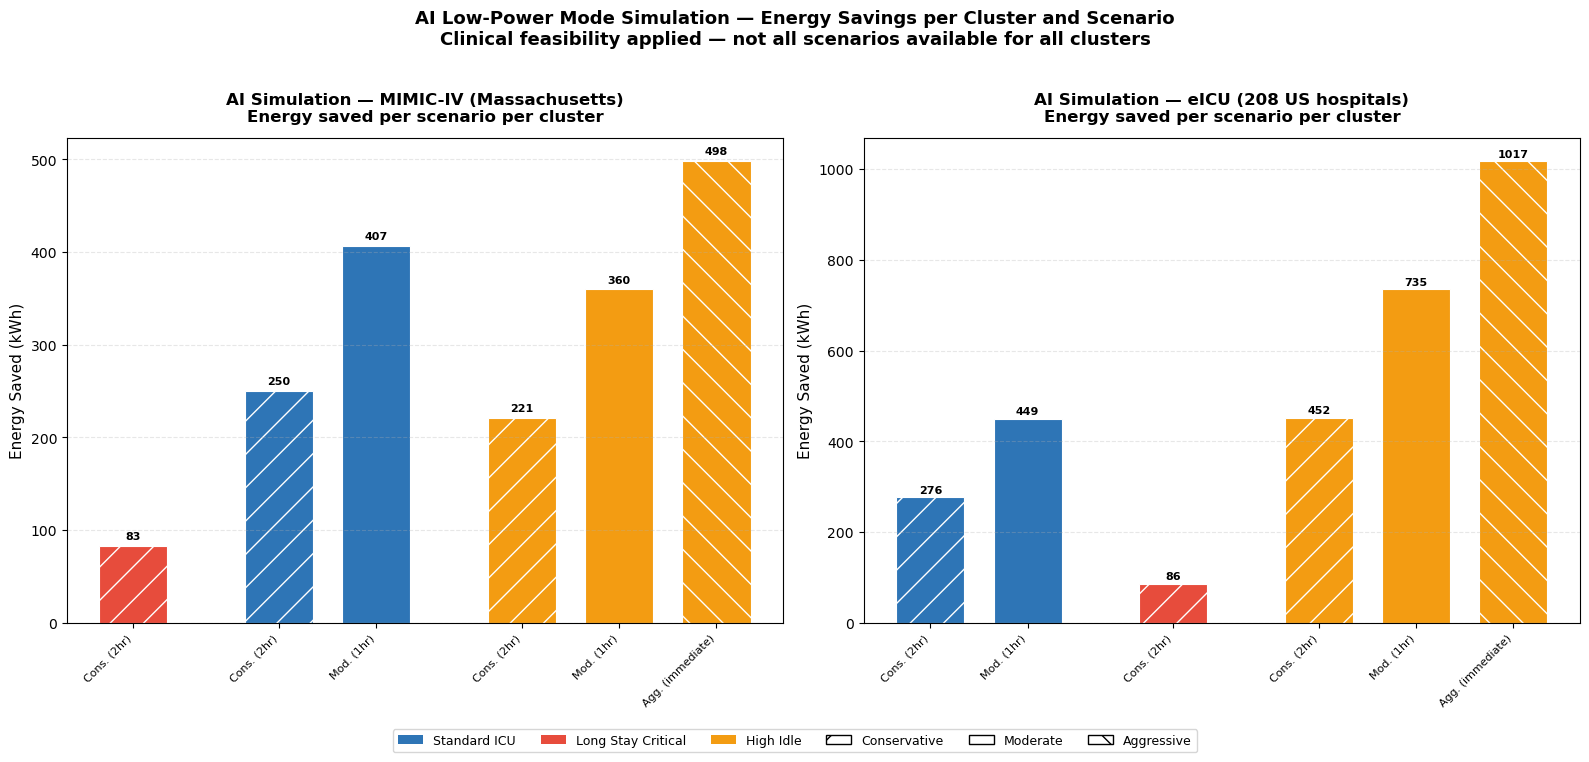

Simulation visualisation saved to Desktop!


In [17]:
# I will build a visualisation showing simulation results per cluster

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# I will define colors per cluster
cluster_colors_sim = {
    'Long Stay Critical (low idle, very long LOS)': '#E74C3C',
    'Long Stay (low idle, long LOS)':               '#E74C3C',
    'Standard ICU (low idle, typical LOS)':         '#2E75B6',
    'High Idle (high idle %, Neuro dominant)':       '#F39C12',
    'High Idle (very high idle %)':                  '#F39C12'
}

scenario_patterns = {
    'Conservative (2hr threshold)': '/',
    'Moderate (1hr threshold)':     '',
    'Aggressive (immediate)':       '\\'
}

for ax, df_sim, dataset in zip(
    axes,
    [df_mimic_sim, df_eicu_sim],
    ['MIMIC-IV (Massachusetts)', 'eICU (208 US hospitals)']
):
    x_positions = []
    bar_heights = []
    bar_colors = []
    bar_labels = []
    hatches = []
    x = 0

    for cluster_id in sorted(df_sim['cluster_id'].unique()):
        cluster_rows = df_sim[df_sim['cluster_id'] == cluster_id]
        cluster_name = cluster_rows['cluster_name'].iloc[0]
        color = cluster_colors_sim.get(cluster_name, '#888888')

        for _, row in cluster_rows.iterrows():
            x_positions.append(x)
            bar_heights.append(row['energy_saved_kwh'])
            bar_colors.append(color)
            bar_labels.append(
                row['scenario'].replace(' threshold', '').replace('Conservative', 'Cons.').replace('Moderate', 'Mod.').replace('Aggressive', 'Agg.')
            )
            hatches.append(scenario_patterns[row['scenario']])
            x += 1
        x += 0.5

    bars = ax.bar(
        x_positions,
        bar_heights,
        color=bar_colors,
        edgecolor='white',
        linewidth=0.8,
        width=0.7
    )

    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)

    for bar, val in zip(bars, bar_heights):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f'{val:.0f}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Energy Saved (kWh)', fontsize=11)
    ax.set_title(
        f'AI Simulation — {dataset}\nEnergy saved per scenario per cluster',
        fontsize=12, fontweight='bold', pad=12
    )
    ax.grid(axis='y', alpha=0.3, linestyle='--')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E75B6', label='Standard ICU'),
    Patch(facecolor='#E74C3C', label='Long Stay Critical'),
    Patch(facecolor='#F39C12', label='High Idle'),
    Patch(facecolor='white', edgecolor='black', hatch='/', label='Conservative'),
    Patch(facecolor='white', edgecolor='black', hatch='', label='Moderate'),
    Patch(facecolor='white', edgecolor='black', hatch='\\', label='Aggressive')
]
fig.legend(
    handles=legend_elements,
    loc='lower center', ncol=6,
    fontsize=9, bbox_to_anchor=(0.5, -0.05)
)

fig.suptitle(
    'AI Low-Power Mode Simulation — Energy Savings per Cluster and Scenario\n'
    'Clinical feasibility applied — not all scenarios available for all clusters',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz_simulation_results.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Simulation visualisation saved to Desktop!")

## Simulation Summary — Key Findings

### MIMIC-IV Maximum Saving (best scenario per cluster)
- Long Stay Critical — Conservative: 83 kWh | 20 kg CO2
- Standard ICU — Moderate: 407 kWh | 100 kg CO2
- High Idle — Aggressive: 498 kWh | 122 kg CO2
- Combined total: 988 kWh | 242 kg CO2

### eICU Maximum Saving (best scenario per cluster)
- Long Stay — Conservative: 86 kWh | 30 kg CO2
- Standard ICU — Moderate: 449 kWh | 156 kg CO2
- High Idle — Aggressive: 1,017 kWh | 354 kg CO2
- Combined total: 1,553 kWh | 540 kg CO2

### Combined Maximum Across Both Datasets
- Total energy saved: 2,541 kWh
- Total CO2 saved: 782 kg

### Clinical Feasibility Note
I applied different scenarios to different clusters based on clinical 
risk. The High Idle cluster — predominantly step-down patients with 
stable vitals — is the only cluster where the aggressive scenario is 
clinically defensible. The Long Stay Critical cluster is restricted to 
the Conservative scenario only given the higher risk of sudden 
deterioration in complex long-term patients. This clinical feasibility 
reasoning will be discussed in detail in my thesis discussion section 
with input from my Philips supervisor.

### Cross-Dataset Consistency
The High Idle cluster produces the highest savings in both datasets — 
confirming that targeting this archetype is the most impactful 
intervention regardless of the hospital system or data source.